# 08 - SHAP Analysis

In this notebook, we use **SHAP (SHapley Additive exPlanations)** to interpret our best performing XGBoost model and understand the key drivers behind Home Credit Default Risk.

**Questions Answered:**
- What are the top risk factors globally?
- Which features increase risk and which features decrease risk?
- Why did the model predict default for specific individuals?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

# Initialize JS for SHAP plots
shap.initjs()

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Prepare Model

We will load the feature engineered data and retrain our best XGBoost model with the optimal hyperparameters found in Notebook 06.

In [2]:
RANDOM_STATE = 42

# Load data
train = pd.read_csv('train_fe.csv')

X = train.drop(columns=['SK_ID_CURR', 'TARGET'])
y = train['TARGET']

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training shape: {X_train.shape}')
print(f'Validation shape: {X_val.shape}')

Training shape: (246008, 64)
Validation shape: (61503, 64)


In [3]:
# Train best XGBoost model
best_xgb = XGBClassifier(
    colsample_bytree=0.885298,
    gamma=1.521570,
    learning_rate=0.067464,
    max_depth=5,
    min_child_weight=1,
    n_estimators=114,
    scale_pos_weight=6.108908,
    subsample=0.775735,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


## 2. Compute SHAP Values

TreeExplainer is a fast and exact method to compute SHAP values for trees and ensembles of trees.

In [4]:
# Sample validation data for faster SHAP computation
# 1000 samples provide a good representative view without taking too much time
X_sample = X_val.sample(n=1000, random_state=RANDOM_STATE)
y_sample = y_val.loc[X_sample.index]

# Create explainer and compute SHAP values
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed!")

SHAP values computed!


## 3. Global Interpretability

### 3.1 Feature Importance (Global Risk Factors)
The bar plot below shows the mean absolute SHAP value for each feature. This answers **"What are the top risk factors globally?"**

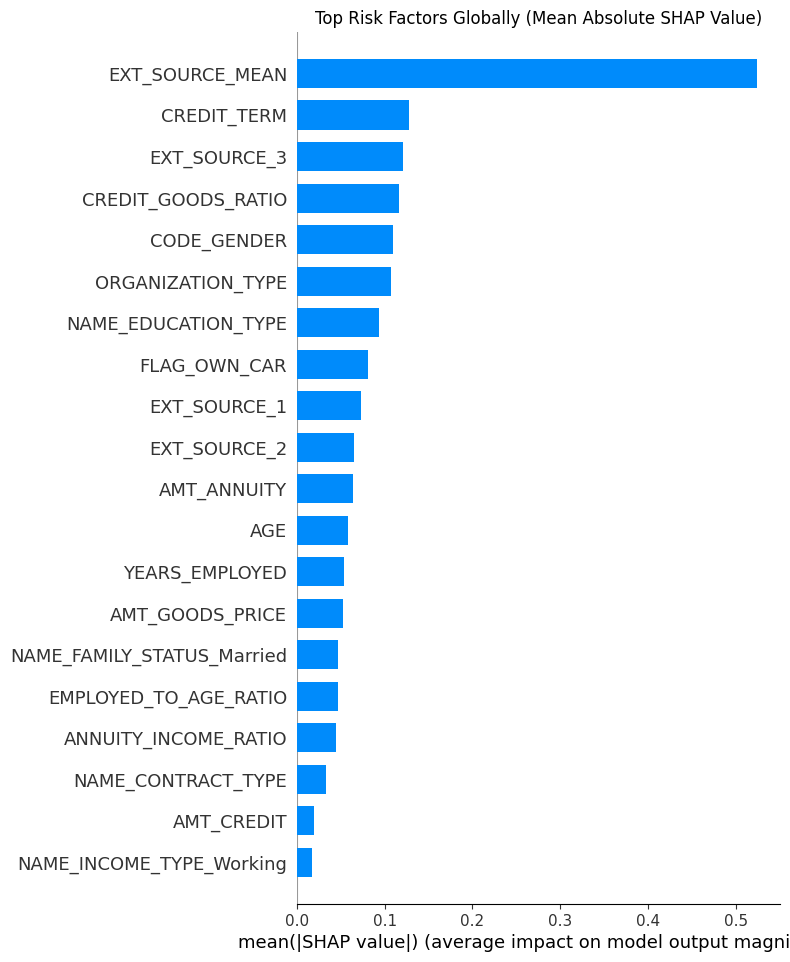

In [5]:
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('Top Risk Factors Globally (Mean Absolute SHAP Value)')
plt.show()

### 3.2 Summary Plot (Direction of Effect)
The summary plot answers **"Which features increase risk?"** and **"Which features decrease risk?"**

- **Red dots:** High feature value
- **Blue dots:** Low feature value
- **Right side of 0.0:** Increases risk of default (SHAP value > 0)
- **Left side of 0.0:** Decreases risk of default (SHAP value < 0)

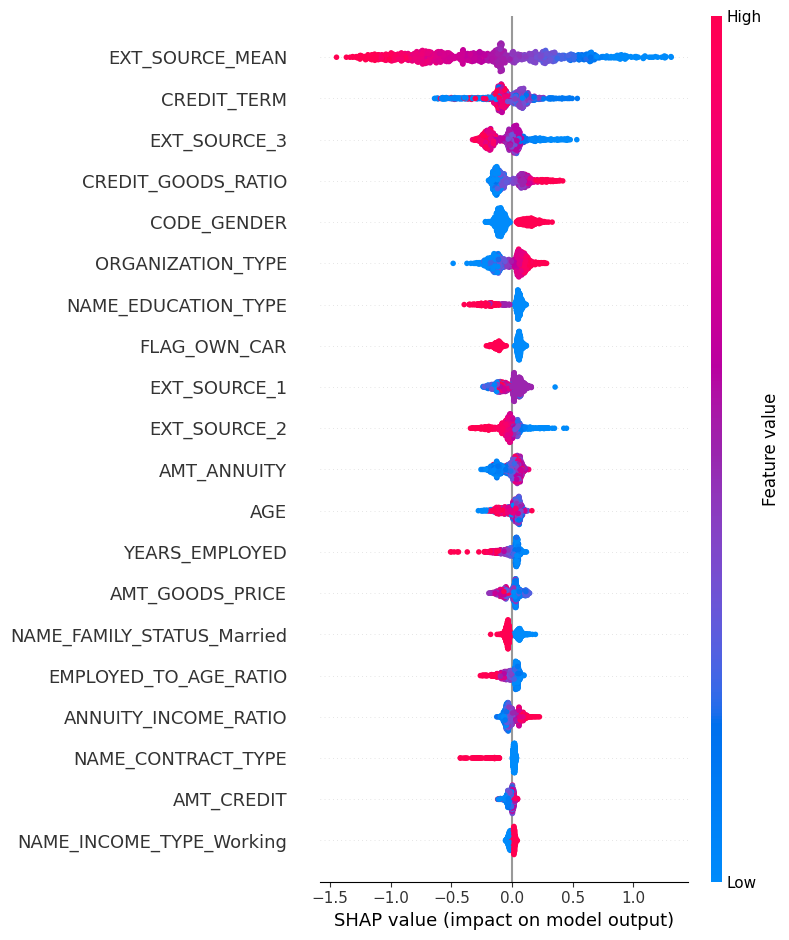

In [6]:
shap.summary_plot(shap_values, X_sample)

### 3.3 Dependence Plot
Let's look at how a specific top feature (e.g., EXT_SOURCE_MEAN) affects the prediction across its different values.

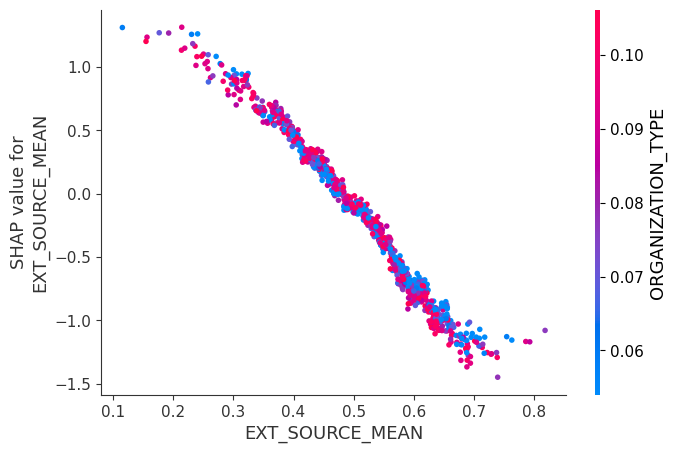

In [7]:
shap.dependence_plot("EXT_SOURCE_MEAN", shap_values, X_sample)

## 4. Local Interpretability (Individual Predictions)

We can use force plots to explain individual predictions. This answers **"Why did the model predict default for this specific customer?"**

- Features in **red** push the prediction higher (towards default)
- Features in **blue** push the prediction lower (towards non-default)

### Example 1: High Risk Customer (Default)

In [8]:
# Get probabilities for the sample
probas = best_xgb.predict_proba(X_sample)[:, 1]

# Find a customer who actually defaulted and had a high predicted probability
high_risk_indices = np.where((y_sample == 1) & (probas > 0.6))[0]

if len(high_risk_indices) > 0:
    idx = high_risk_indices[0]
    print(f"Customer Index: {X_sample.index[idx]}")
    print(f"Predicted Probability: {probas[idx]:.4f}")
    print(f"Actual Status: Default")
    display(shap.force_plot(explainer.expected_value, shap_values[idx,:], X_sample.iloc[idx,:]))
else:
    print("No high risk defaults found in this sample. Please try a different sample size or random state.")

Customer Index: 101924
Predicted Probability: 0.6895
Actual Status: Default


### Example 2: Low Risk Customer (Non-Default)

In [9]:
# Find a customer who did not default and had a low predicted probability
low_risk_indices = np.where((y_sample == 0) & (probas < 0.2))[0]

if len(low_risk_indices) > 0:
    idx = low_risk_indices[0]
    print(f"Customer Index: {X_sample.index[idx]}")
    print(f"Predicted Probability: {probas[idx]:.4f}")
    print(f"Actual Status: Non-Default")
    display(shap.force_plot(explainer.expected_value, shap_values[idx,:], X_sample.iloc[idx,:]))
else:
    print("No low risk non-defaults found in this sample.")

Customer Index: 208806
Predicted Probability: 0.1125
Actual Status: Non-Default
